In [5]:
import torch

import os
import random
from pathlib import Path
import time

import numpy as np
import cv2
import matplotlib.pyplot as plt

from facenet_pytorch import MTCNN

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.2.2+cu121
CUDA: True
CUDA version: 12.1
OpenCV: 4.9.0
NumPy: 1.26.4
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

detector = MTCNN(
    keep_all=True,
    device=device
)

Using: cuda


In [7]:
dataset_path = Path(r"C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\raw\VGGFace2 (recognition_dataset)")
train_path = dataset_path/"train"
val_path = dataset_path/"val"

train_folders = list(train_path.iterdir())
sample_identity = train_folders[0]
sample_images = list(sample_identity.iterdir())

img_path = Path(sample_images[0])
img = cv2.imread(str(img_path))

processed_root = Path(r"C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\data\processed\VGGFace2_160")
processed_train = processed_root/"train"
processed_val = processed_root/"val"

processed_train.mkdir(parents = True, exist_ok = True)
processed_val.mkdir(parents = True, exist_ok = True)

print(processed_root)

print(img_path)
print(img.shape)

C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\data\processed\VGGFace2_160
C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\raw\VGGFace2 (recognition_dataset)\train\n000002\0001_01.jpg
(622, 544, 3)


In [8]:
train_images = sum(len(list(folder.iterdir())) for folder in train_path.iterdir() if folder.is_dir())
val_images = sum(len(list(folder.iterdir())) for folder in val_path.iterdir() if folder.is_dir())

print("Train:", train_images)
print("Val:", val_images)
print("Total:", train_images + val_images)

Train: 176181
Val: 21268
Total: 197449


In [9]:
def get_main_face_box(boxes):
    if boxes is None:
        return None

    if len(boxes) == 1:
        return boxes[0]

    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    return boxes[np.argmax(areas)]

In [10]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

boxes, probs = detector.detect(img_rgb)

print("Boxes:", boxes)
print("Probs:", probs)

Boxes: [[160.32485961914062 146.7068328857422 387.5979309082031
  463.44366455078125]]
Probs: [0.9997785687446594]


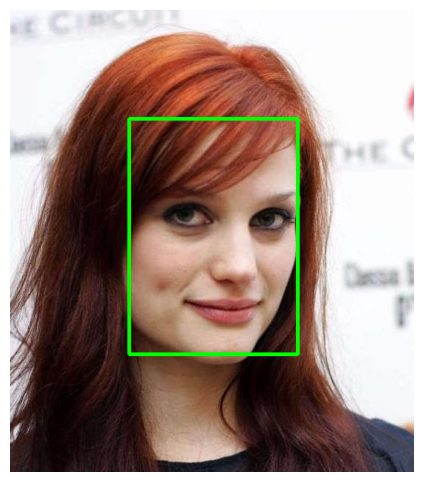

In [11]:
img_copy = img.copy()

bbox = get_main_face_box(boxes).astype(int)

x1, y1, x2, y2 = bbox

cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [12]:
def crop_face(img, bbox, margin=0.1):
    h, w = img.shape[:2]

    x1, y1, x2, y2 = bbox.astype(int)

    box_w = x2 - x1
    box_h = y2 - y1

    dx = int(box_w * margin)
    dy = int(box_h * margin)

    x1 = max(0, x1 - dx)
    y1 = max(0, y1 - dy)
    x2 = min(w, x2 + dx)
    y2 = min(h, y2 + dy)

    return img[y1:y2, x1:x2]

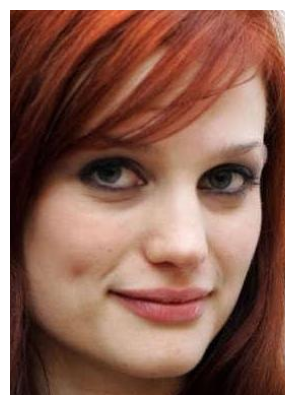

In [13]:
cropped_face = crop_face(img, bbox)

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [14]:
sample_paths = []

random_folders = random.sample(train_folders, 15)

for folder in random_folders:
    images = list(folder.iterdir())
    sample_paths.append(random.choice(images))

print(len(sample_paths))

15


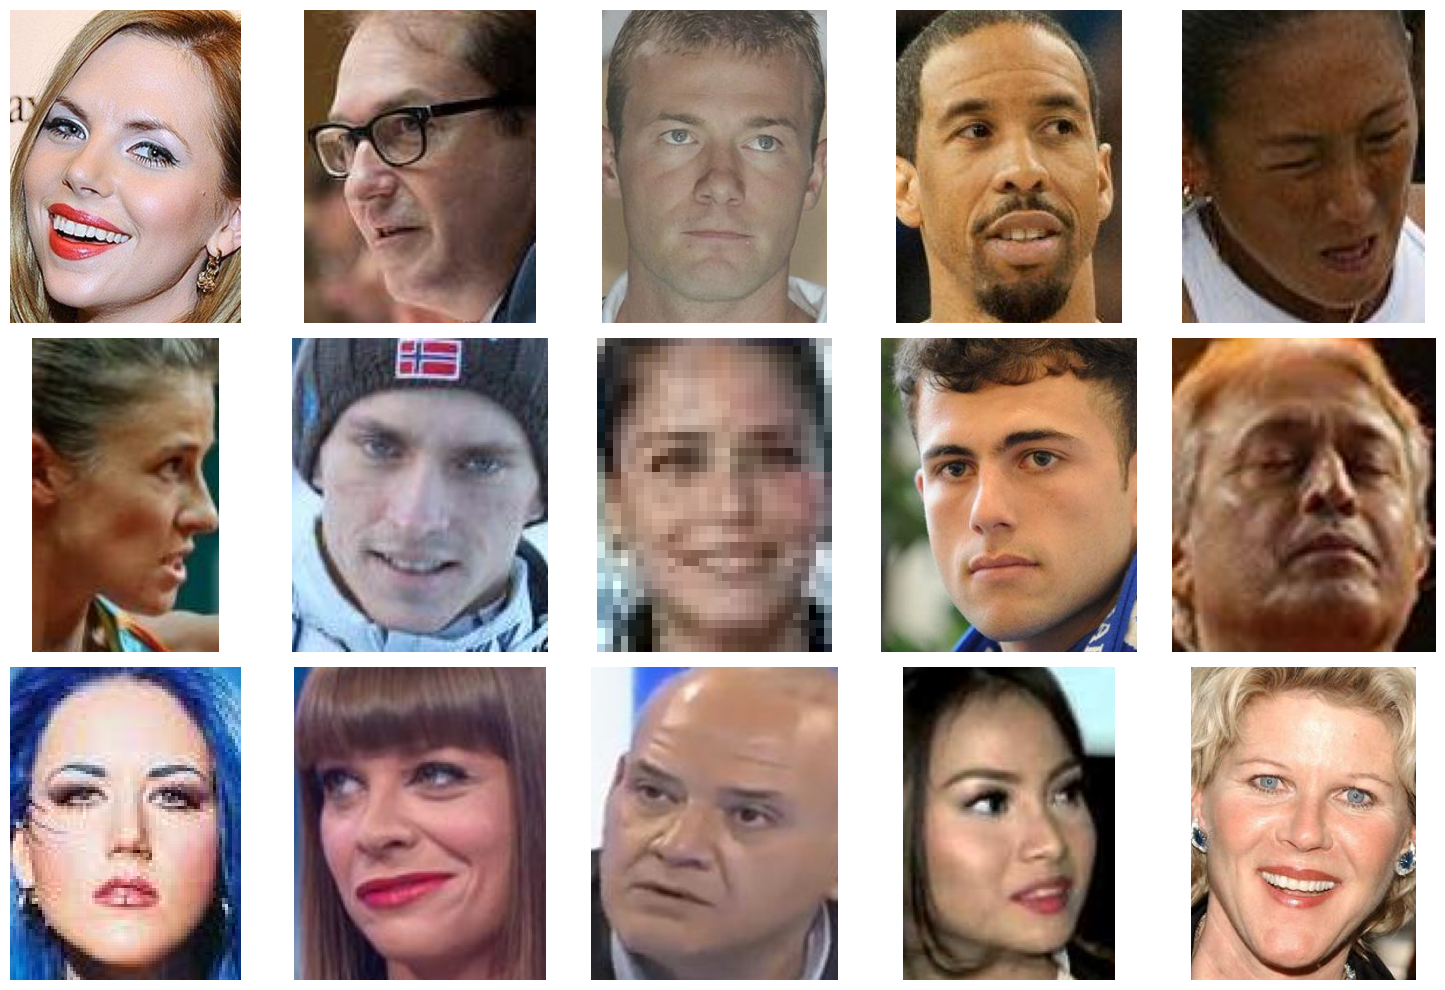

In [15]:
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i, img_path in enumerate(sample_paths):
    img = cv2.imread(str(img_path))

    if img is None:
        axes[i].set_title("Read Error")
        axes[i].axis("off")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    boxes, probs = detector.detect(img_rgb)

    if boxes is None:
        axes[i].set_title("No face")
        axes[i].axis("off")
        continue

    bbox = get_main_face_box(boxes)

    cropped = crop_face(img, bbox)

    axes[i].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [17]:
def get_border_mean_color(img, border=5):
    h, w = img.shape[:2]

    top = img[:border, :]
    bottom = img[h-border:, :]
    left = img[:, :border]
    right = img[:, w-border:]

    border_pixels = np.concatenate([
        top.reshape(-1, 3),
        bottom.reshape(-1, 3),
        left.reshape(-1, 3),
        right.reshape(-1, 3)
    ], axis=0)

    return border_pixels.mean(axis=0).astype(np.uint8).tolist()


def pad_to_sqr(img):
    h, w = img.shape[:2]

    if h == w:
        return img

    size = max(h, w)

    pad_top = (size - h) // 2
    pad_bottom = size - h - pad_top

    pad_left = (size - w) // 2
    pad_right = size - w - pad_left

    pad_color = get_border_mean_color(img)

    padded = cv2.copyMakeBorder(
        img,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        cv2.BORDER_CONSTANT,
        value=pad_color
    )

    return padded

Before:  (379, 271, 3)
After:  (379, 379, 3)


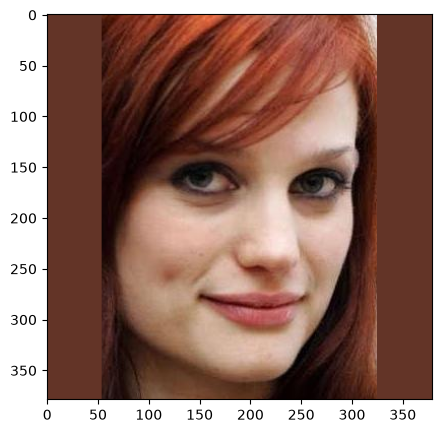

In [18]:
padded_face = pad_to_sqr(cropped_face)

print("Before: ", cropped_face.shape)
print("After: ", padded_face.shape)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(padded_face, cv2.COLOR_BGR2RGB))

After Resize:  (160, 160, 3)


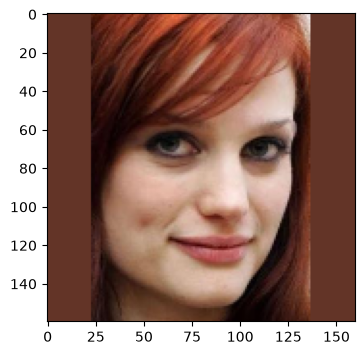

In [19]:
resized_face = cv2.resize(padded_face, (160, 160))

print("After Resize: ", resized_face.shape)

plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(resized_face, cv2.COLOR_BGR2RGB))
plt.axis="off"
plt.show()

In [20]:
normalized_face = resized_face.astype(np.float32) / 255.0

print("Shape: ", normalized_face.shape)
print("DType: ", normalized_face.dtype)
print("Min: ", normalized_face.min())
print("Max: ", normalized_face.max())

Shape:  (160, 160, 3)
DType:  float32
Min:  0.0
Max:  1.0


In [21]:
def preprocess_image(img_path, detector, margin=0.2, target_size=(160, 160)):
    img = cv2.imread(str(img_path))

    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    boxes, probs = detector.detect(img_rgb)

    if boxes is None:
        return None

    bbox = get_main_face_box(boxes)

    cropped = crop_face(img, bbox, margin)

    padded = pad_to_sqr(cropped)

    resized = cv2.resize(padded, target_size)

    return resized

In [22]:
processed_face = preprocess_image(sample_paths[0], detector=detector)

print(processed_face.shape)
print(processed_face.dtype)

(160, 160, 3)
uint8


In [23]:
def process_dataset(src_root, dst_root, detector, max_folders=None):
    total = 0
    processed = 0
    skipped = 0
    failed_files = []
    start_time = time.time()

    identity_folders = [f for f in src_root.iterdir() if f.is_dir()]

    if max_folders is not None:
        identity_folders = identity_folders[:max_folders]

    total_folders = len(identity_folders)

    for idx, folder in enumerate(identity_folders):
        dst_folder = dst_root / folder.name

        # Resume support: skip if folder already processed
        if dst_folder.exists() and any(dst_folder.iterdir()):
            print(f"[{idx+1}/{total_folders}] Skipping existing folder: {folder.name}")
            continue

        dst_folder.mkdir(parents=True, exist_ok=True)

        image_paths = list(folder.iterdir())

        for image_path in image_paths:
            total += 1

            processed_img = preprocess_image(image_path, detector)

            if processed_img is None:
                skipped += 1
                failed_files.append(str(image_path))
                continue

            save_path = dst_folder / (image_path.stem + ".jpg")

            cv2.imwrite(
                str(save_path),
                processed_img,
                [cv2.IMWRITE_JPEG_QUALITY, 95]
            )

            processed += 1

        # Progress log every 10 folders
        if (idx + 1) % 10 == 0 or (idx + 1) == total_folders:
            elapsed = time.time() - start_time
            speed = processed / elapsed if elapsed > 0 else 0

            print(
                f"[{idx+1}/{total_folders}] "
                f"Processed: {processed} | "
                f"Skipped: {skipped} | "
                f"Speed: {speed:.2f} img/s"
            )

    elapsed = time.time() - start_time

    print("\n========== DONE ==========")
    print(f"Elapsed time: {elapsed/60:.2f} minutes")
    print(f"Total images seen: {total}")
    print(f"Processed images: {processed}")
    print(f"Skipped images: {skipped}")

    # Save failed file list
    if failed_files:
        failed_path = dst_root / "failed_files.txt"

        with open(failed_path, "w", encoding="utf-8") as f:
            for file in failed_files:
                f.write(file + "\n")

        print(f"Failed files saved to: {failed_path}")

In [24]:
process_dataset(train_path, processed_train, detector, max_folders=3)

[3/3] Processed: 903 | Skipped: 1 | Speed: 7.34 img/s

========== DONE ==========
Elapsed time: 2.05 minutes
Total images seen: 904
Processed images: 903
Skipped images: 1
Failed files saved to: C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\data\processed\VGGFace2_160\train\failed_files.txt


In [45]:
process_dataset(
    train_path,
    processed_train,
    detector
)

[1/480] Skipping existing folder: n000002
[2/480] Skipping existing folder: n000003
[3/480] Skipping existing folder: n000004
[10/480] Processed: 2157 | Skipped: 2 | Speed: 6.76 img/s
[20/480] Processed: 5561 | Skipped: 5 | Speed: 6.78 img/s
[30/480] Processed: 9177 | Skipped: 9 | Speed: 6.77 img/s
[40/480] Processed: 12606 | Skipped: 10 | Speed: 6.91 img/s
[50/480] Processed: 15991 | Skipped: 19 | Speed: 7.00 img/s
[60/480] Processed: 19906 | Skipped: 20 | Speed: 6.94 img/s
[70/480] Processed: 23475 | Skipped: 24 | Speed: 7.02 img/s
[80/480] Processed: 27702 | Skipped: 26 | Speed: 7.24 img/s
[90/480] Processed: 30993 | Skipped: 32 | Speed: 7.18 img/s
[100/480] Processed: 35206 | Skipped: 35 | Speed: 7.16 img/s
[110/480] Processed: 38903 | Skipped: 35 | Speed: 7.16 img/s
[120/480] Processed: 42137 | Skipped: 43 | Speed: 7.17 img/s
[130/480] Processed: 45048 | Skipped: 46 | Speed: 7.17 img/s
[140/480] Processed: 48892 | Skipped: 52 | Speed: 7.15 img/s
[150/480] Processed: 52742 | Skippe

In [46]:
process_dataset(
    val_path,
    processed_val,
    detector
)

[10/60] Processed: 3835 | Skipped: 11 | Speed: 7.87 img/s
[20/60] Processed: 7203 | Skipped: 24 | Speed: 8.40 img/s
[30/60] Processed: 10980 | Skipped: 29 | Speed: 8.68 img/s
[40/60] Processed: 14371 | Skipped: 37 | Speed: 8.71 img/s
[50/60] Processed: 17298 | Skipped: 42 | Speed: 8.90 img/s
[60/60] Processed: 21249 | Skipped: 46 | Speed: 8.67 img/s

========== DONE ==========
Elapsed time: 40.84 minutes
Total images seen: 21295
Processed images: 21249
Skipped images: 46
Failed files saved to: C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\data\processed\VGGFace2_160\val\failed_files.txt
